<a href="https://colab.research.google.com/github/mahigarg0403-blip/Customer-purchase-prediction_mahi_bhumika/blob/main/notebooks/step7_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.model_selection import GridSearchCV
import joblib
import shutil
import warnings
warnings.filterwarnings('ignore')

path = '/content/drive/MyDrive/CPP-ML PROJECT-BHUMIKA-MAHI/'

Mounted at /content/drive


In [2]:
X_train = pd.read_csv(path + 'step 4/x_train_tree_final.csv')
X_test = pd.read_csv(path + 'step 4/x_test_tree_final.csv')
y_train = pd.read_csv(path + 'step 4/y_train_tree_final.csv').values.ravel()
y_test = pd.read_csv(path + 'step 4/y_test_tree_final.csv').values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:", pd.Series(y_train).value_counts().to_dict())
print("y_test distribution:", pd.Series(y_test).value_counts().to_dict())

X_train shape: (16476, 21)
X_test shape: (2441, 21)
y_train distribution: {1: 8238, 0: 8238}
y_test distribution: {0: 2059, 1: 382}


In [3]:
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_base.fit(X_train, y_train)
y_pred_base = xgb_base.predict(X_test)
y_prob_base = xgb_base.predict_proba(X_test)[:, 1]

print("BASE XGBOOST RESULTS (before tuning):")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_prob_base):.4f}")

BASE XGBOOST RESULTS (before tuning):
Accuracy:  0.8857
F1:        0.6543
Precision: 0.6212
Recall:    0.6911
AUC:       0.9204


In [35]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb

# We will test a range for scale_pos_weight to find the sweet spot
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 2, 3] # Testing lower weights since X_train is 50/50
}

xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Optimized Parameters:", grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Optimized Parameters: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 300, 'scale_pos_weight': 1}


In [36]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# 1. Get the best model from the grid search
best_xgb = grid_search.best_estimator_

# 2. Predict on the test set
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# 3. Print the comparison
print("TUNED XGBOOST RESULTS (On Test Set):")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"F1:        {f1_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_prob_tuned):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned))

TUNED XGBOOST RESULTS (On Test Set):
Accuracy:  0.8808
F1:        0.6403
Precision: 0.6066
Recall:    0.6780
AUC:       0.9215

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2059
           1       0.61      0.68      0.64       382

    accuracy                           0.88      2441
   macro avg       0.77      0.80      0.78      2441
weighted avg       0.89      0.88      0.88      2441



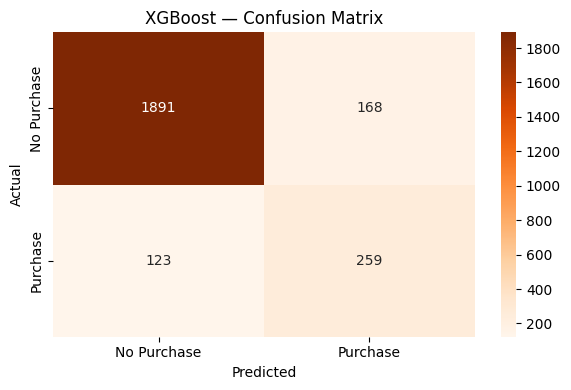

In [41]:
# Change y_pred to y_pred_tuned so the plot matches your new results!
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Purchase', 'Purchase'],
            yticklabels=['No Purchase', 'Purchase'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150)
plt.show()

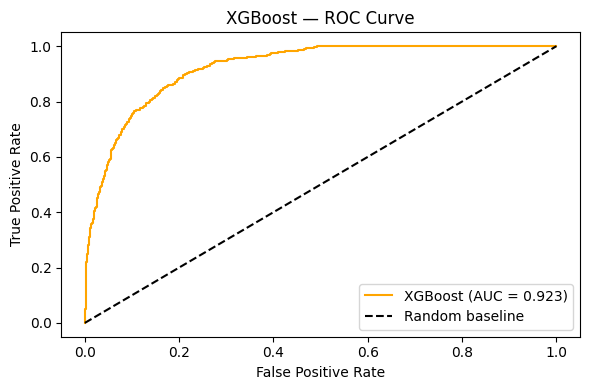

In [38]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='orange', label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost — ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('xgb_roc_curve.png', dpi=150)
plt.show()

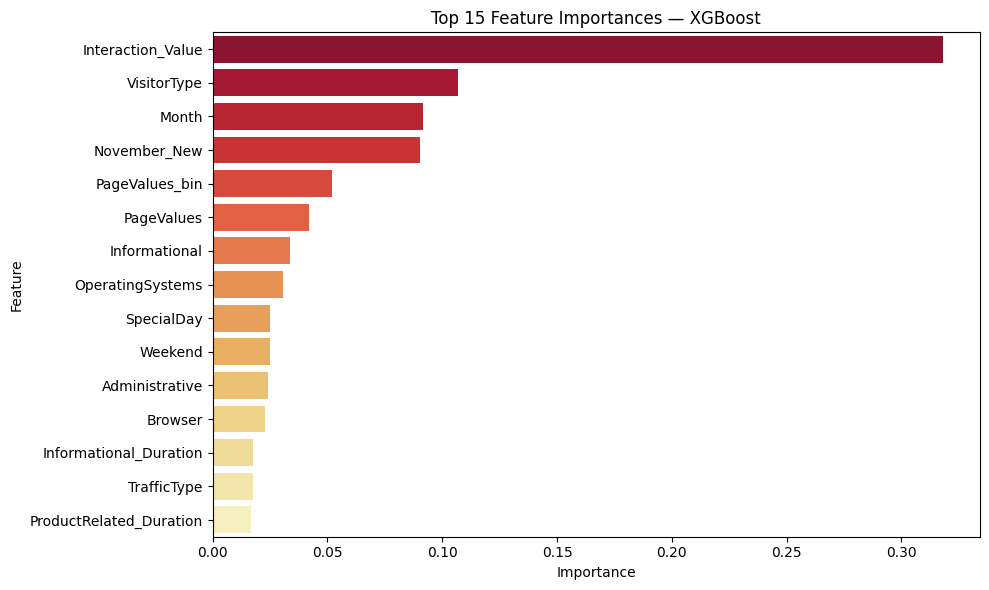

Top 10 features:
              Feature  Importance
18  Interaction_Value    0.318278
14        VisitorType    0.106677
9               Month    0.091832
20       November_New    0.090274
16     PageValues_bin    0.051983
7          PageValues    0.042081
2       Informational    0.033670
10   OperatingSystems    0.030554
8          SpecialDay    0.025151
15            Weekend    0.024873


In [39]:
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feat_imp.head(15), palette='YlOrRd_r')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
print(feat_imp.head(10))

In [40]:
joblib.dump(best_xgb, 'xgboost.pkl')
shutil.copy('xgboost.pkl', path + 'xgboost.pkl')

results = pd.DataFrame([{
    'Model': 'XGBoost',
    'Accuracy': round(accuracy, 4),
    'F1': round(f1, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'AUC': round(auc, 4)
}])

results.to_csv('xgb_results.csv', index=False)
shutil.copy('xgb_results.csv', path + 'xgb_results.csv')

for plot in ['xgb_confusion_matrix.png', 'xgb_roc_curve.png', 'xgb_feature_importance.png']:
    shutil.copy(plot, path + plot)

print("All saved to Drive ✅")
print(results)

All saved to Drive ✅
     Model  Accuracy      F1  Precision  Recall    AUC
0  XGBoost    0.8615  0.6373       0.54  0.7775  0.923
